MNIST image
   ↓
28 × 28 pixels
   ↓
Flatten → 784 features
   ↓
Linear(784 → 128)
   ↓
ReLU
   ↓
Linear(128 → 64)
   ↓
ReLU
   ↓
Linear(64 → 10)
   ↓
10 digit classes
   ↓
Prediction: 0–9

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

print("PyTorch version:", torch.__version__)

PyTorch version: 2.13.0


In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)


Using device: mps


In [3]:
transform = transforms.ToTensor()

In [4]:
full_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

100.0%
100.0%
100.0%
100.0%


look at the dataset 

In [5]:
print("Dataset size:", len(full_dataset))

Dataset size: 60000


In [6]:
image, label = full_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)

Image shape: torch.Size([1, 28, 28])
Label: 5


In [7]:
train_size = 50000
val_size = 10000

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size]
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Training samples: 50000
Validation samples: 10000


In [8]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [9]:
images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([64, 1, 28, 28])
Labels: torch.Size([64])


In [10]:
class MLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.layer1 = nn.Linear(28 * 28, 128)

        self.relu1 = nn.ReLU()

        self.layer2 = nn.Linear(128, 64)

        self.relu2 = nn.ReLU()

        self.output = nn.Linear(64, 10)

    def forward(self, x):

        x = self.flatten(x)

        x = self.layer1(x)

        x = self.relu1(x)

        x = self.layer2(x)

        x = self.relu2(x)

        x = self.output(x)

        return x

In [11]:
model = MLP().to(device)

print(model)

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layer1): Linear(in_features=784, out_features=128, bias=True)
  (relu1): ReLU()
  (layer2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (output): Linear(in_features=64, out_features=10, bias=True)
)


In [12]:
loss_fn = nn.CrossEntropyLoss()

In [13]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

Trainning loop

In [14]:
epochs = 5

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

one epoch

In [15]:
for epoch in range(epochs):

    # ==========================
    # Training
    # ==========================

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = loss_fn(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()

        total += labels.size(0)

    train_loss = running_loss / len(train_loader)

    train_accuracy = correct / total

    train_losses.append(train_loss)

    train_accuracies.append(train_accuracy)

In [16]:
    # ==========================
    # Validation
    # ==========================

    model.eval()

    val_running_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = loss_fn(outputs, labels)

            val_running_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            val_correct += (
                (predictions == labels).sum().item()
            )

            val_total += labels.size(0)

    val_loss = val_running_loss / len(val_loader)

    val_accuracy = val_correct / val_total

    val_losses.append(val_loss)

    val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch 5/5 | Train Loss: 0.0606 | Train Acc: 0.9810 | Val Loss: 0.0998 | Val Acc: 0.9696


In [17]:
import matplotlib.pyplot as plt

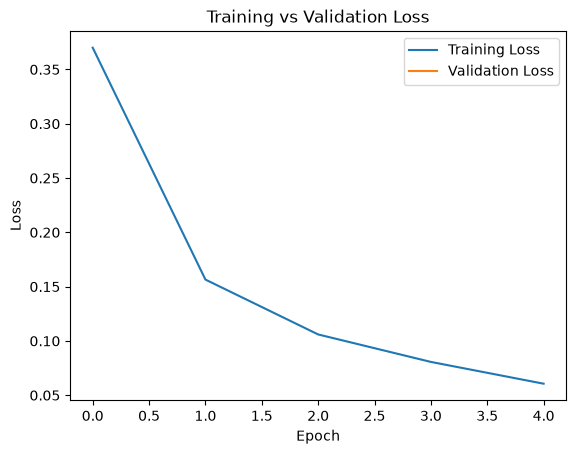

In [18]:
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

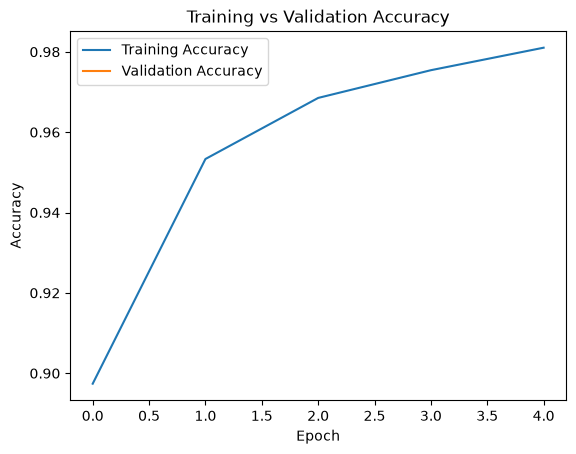

In [19]:
plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

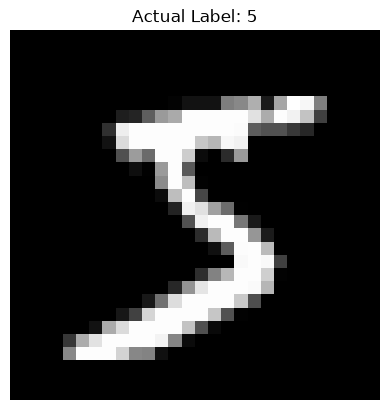

In [20]:
image, label = full_dataset[0]

plt.imshow(image.squeeze(), cmap="gray")

plt.title(f"Actual Label: {label}")

plt.axis("off")

plt.show()

In [21]:
model.eval()

with torch.no_grad():

    image_input = image.unsqueeze(0).to(device)

    output = model(image_input)

    prediction = output.argmax(dim=1).item()

print("Actual:", label)
print("Predicted:", prediction)

Actual: 5
Predicted: 5


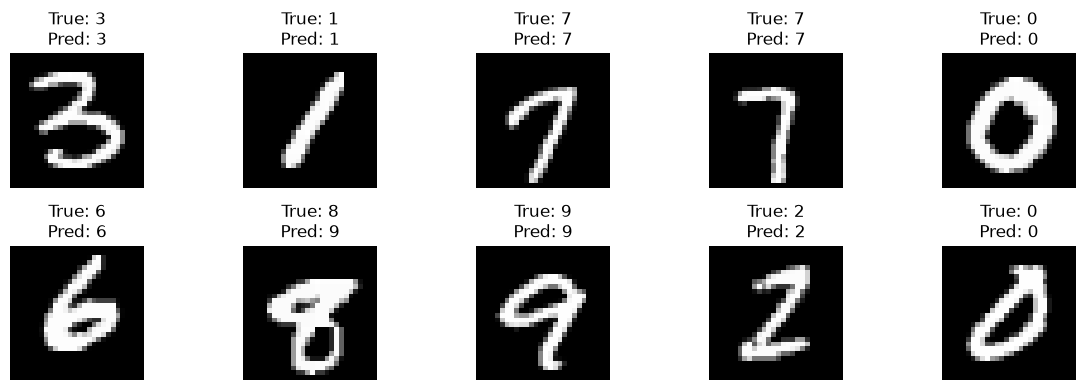

In [22]:
images, labels = next(iter(val_loader))

images = images.to(device)

with torch.no_grad():

    outputs = model(images)

    predictions = outputs.argmax(dim=1)

images = images.cpu()

plt.figure(figsize=(12, 4))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(images[i].squeeze(), cmap="gray")

    plt.title(
        f"True: {labels[i]}\n"
        f"Pred: {predictions[i].cpu()}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()